# AI600 – Deep Learning | Assignment 3
**LUMS, Spring 2026**

**Mubeen Ahmed**



## 0. Setup & Imports

In [1]:
# Install required packages (run once)
!pip install grad-cam -q

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import pickle
from PIL import Image
from torchvision.datasets import ImageFolder
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


---
## Task 1A: Custom CNN on Standard MNIST

### 1A.1 – Architecture Design

In [3]:
class MNISTNet(nn.Module):
    """
    Custom CNN for MNIST.
    Constraints: <=3 Conv layers, <=2 FC layers, <=50,000 parameters.
    
    Architecture:
      Conv1: 1->8 channels, 3x3, ReLU, MaxPool 2x2  -> 8x14x14
      Conv2: 8->16 channels, 3x3, ReLU, MaxPool 2x2 -> 16x6x6  (floor((14-2)/2) = 6)
      Conv3: 16->16 channels, 3x3, ReLU             -> 16x4x4
      Flatten                                        -> 256
      FC1: 256->64, ReLU
      FC2: 64->10
    
    Param count:
      Conv1: (3*3*1+1)*8   =  80
      Conv2: (3*3*8+1)*16  = 1168
      Conv3: (3*3*16+1)*16 = 2320
      FC1:   256*64+64     = 16448
      FC2:   64*10+10      =  650
      Total                = 20666  (well under 50k)
    """
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)   # 28x28 -> 28x28
        self.pool  = nn.MaxPool2d(2, 2)                           # halves spatial dims
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)  # 14x14 -> 14x14
        self.conv3 = nn.Conv2d(16, 16, kernel_size=3, padding=0) # 7x7   -> 5x5
        self.fc1   = nn.Linear(16 * 5 * 5, 64)
        self.fc2   = nn.Linear(64, 10)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # -> 8x14x14
        x = self.pool(F.relu(self.conv2(x)))  # -> 16x7x7
        x = F.relu(self.conv3(x))             # -> 16x5x5
        x = x.view(x.size(0), -1)             # -> 400
        x = self.dropout(F.relu(self.fc1(x))) # -> 64
        x = self.fc2(x)                        # -> 10
        return x


# Verify parameter count
model_mnist = MNISTNet().to(device)
total_params = sum(p.numel() for p in model_mnist.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')
assert total_params <= 50000, 'Parameter limit exceeded!'
print('Parameter constraint satisfied ✓')

Total trainable parameters: 29,882
Parameter constraint satisfied ✓


### 1A.2 – Data Loading

In [4]:
# MNIST transforms
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load datasets
full_train = torchvision.datasets.MNIST(root='./data', train=True,
                                         download=True, transform=mnist_transform)
test_set   = torchvision.datasets.MNIST(root='./data', train=False,
                                         download=True, transform=mnist_transform)

# 80/20 train-val split
train_size = int(0.8 * len(full_train))
val_size   = len(full_train) - train_size
train_set, val_set = random_split(full_train, [train_size, val_size],
                                   generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False, num_workers=2)

print(f'Train: {len(train_set):,} | Val: {len(val_set):,} | Test: {len(test_set):,}')

Train: 48,000 | Val: 12,000 | Test: 10,000


### 1A.3 – Training Loop

In [5]:
def train_model(model, train_loader, val_loader, num_epochs=15, lr=1e-3, device=device):
    """Generic training loop; returns history dict."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

    history = {'train_loss': [], 'val_loss': [],
                'train_acc':  [], 'val_acc':  []}

    for epoch in range(num_epochs):
        # ---- Training phase ----
        model.train()
        running_loss = correct = total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc  = 100. * correct / total

        # ---- Validation phase ----
        model.eval()
        val_loss = val_correct = val_total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss    += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total   += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss /= val_total
        val_acc   = 100. * val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        scheduler.step()

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1:2d}/{num_epochs}] '
                  f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')

    return history


print('Training MNISTNet...')
history_mnist = train_model(model_mnist, train_loader, val_loader, num_epochs=15)

Training MNISTNet...
Epoch [ 1/15] Train Loss: 0.3267 Acc: 89.79% | Val Loss: 0.0997 Acc: 96.92%
Epoch [ 5/15] Train Loss: 0.0530 Acc: 98.33% | Val Loss: 0.0441 Acc: 98.67%
Epoch [10/15] Train Loss: 0.0216 Acc: 99.33% | Val Loss: 0.0384 Acc: 98.91%
Epoch [15/15] Train Loss: 0.0131 Acc: 99.58% | Val Loss: 0.0387 Acc: 99.00%


### 1A.4 – Plot Curves & Evaluate

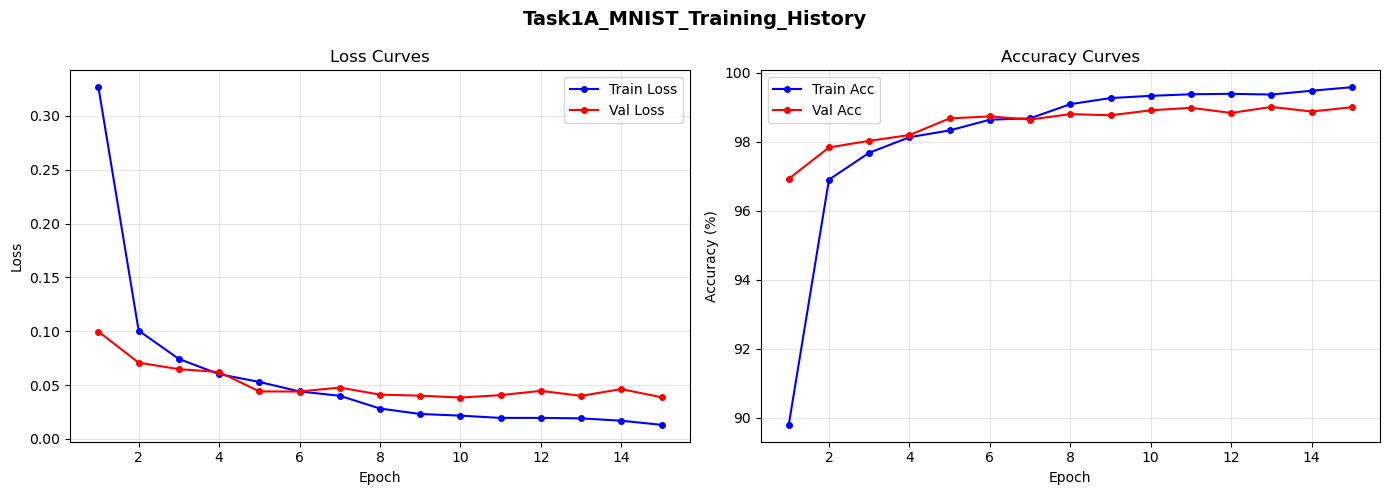


==> MNIST Test Accuracy: 99.27%


In [6]:
def plot_history(history, title='Training History'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
    axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
    axes[0].set_title('Loss Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train Acc', markersize=4)
    axes[1].plot(epochs, history['val_acc'],   'r-o', label='Val Acc',   markersize=4)
    axes[1].set_title('Accuracy Curves')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_history(history_mnist, 'Task1A_MNIST_Training_History')


def evaluate(model, loader, device=device):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            _, predicted = model(inputs).max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total


test_acc = evaluate(model_mnist, test_loader)
print(f'\n==> MNIST Test Accuracy: {test_acc:.2f}%')

### 1A.5 – Analytical Q1.2: First-Layer Filter Visualization

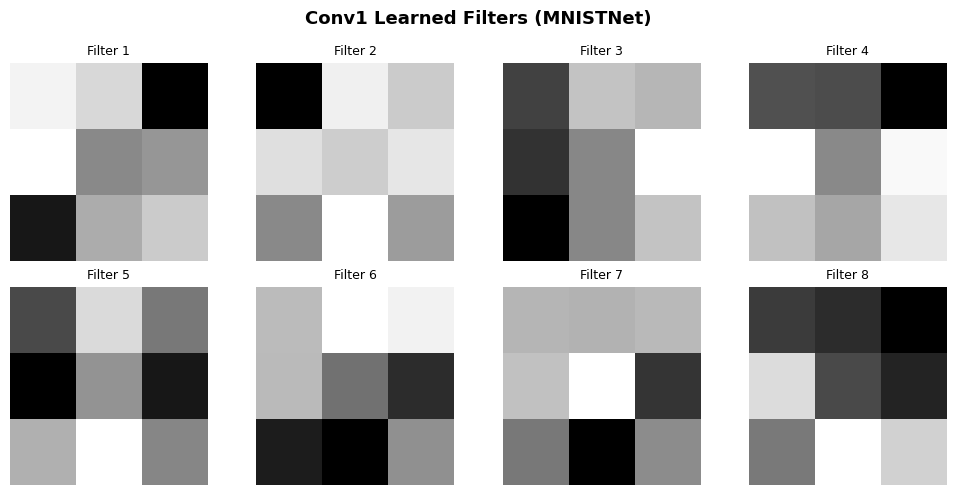

Filters saved as conv1_filters.png


In [7]:
filters = model_mnist.conv1.weight.data.cpu().numpy()  # shape: (8, 1, 3, 3)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    f = filters[i, 0]  # 3x3
    # Normalize to [0,1] for display
    f_norm = (f - f.min()) / (f.max() - f.min() + 1e-8)
    ax.imshow(f_norm, cmap='gray', interpolation='nearest')
    ax.set_title(f'Filter {i+1}', fontsize=9)
    ax.axis('off')

plt.suptitle('Conv1 Learned Filters (MNISTNet)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('conv1_filters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Filters saved as conv1_filters.png')

---
## Task 1B: Colored-MNIST (Shortcut Learning)

In [14]:
import os
import zipfile
import io
import torch
import torch.nn.functional as F_
from torch.utils.data import DataLoader, TensorDataset

def load_cmnist_split(split_dir):
    """
    Handles unzipped PyTorch directories by re-zipping in memory.
    Fixes 'enforce fail' by wrapping all files in a top-level 'archive' directory.
    """
    if not os.path.isdir(split_dir):
        raise FileNotFoundError(f"Split folder not found: {split_dir}")

    buffer = io.BytesIO()
    # PyTorch enforcement requires files to be in a subdirectory inside the ZIP
    top_level_dir = "archive"

    with zipfile.ZipFile(buffer, 'w', compression=zipfile.ZIP_STORED) as zf:
        for root, _, files in os.walk(split_dir):
            for file in files:
                full_path = os.path.join(root, file)
                rel_path = os.path.relpath(full_path, split_dir)
                
                # Prepend 'archive/' to the path inside the ZIP
                archive_path = os.path.join(top_level_dir, rel_path)
                
                # Set timestamp to 1980 and use the new archive path
                zinfo = zipfile.ZipInfo(archive_path, date_time=(1980, 1, 1, 0, 0, 0))
                with open(full_path, 'rb') as f:
                    zf.writestr(zinfo, f.read())
    
    buffer.seek(0)
    data = torch.load(buffer, weights_only=False)

    # ── Unpack the data ──────────────────────────────────────────────────────
    if isinstance(data, TensorDataset):
        images, labels = data.tensors
    elif isinstance(data, dict):
        images = data.get('images', data.get('x', data.get('data')))
        labels = data.get('labels', data.get('y', data.get('targets')))
    elif isinstance(data, (list, tuple)) and len(data) == 2:
        images, labels = data
    else:
        raise ValueError(f"Unrecognised format in {split_dir}")

    # ── Ensure proper tensor types & move to CPU for processing ───────────────
    if not isinstance(images, torch.Tensor):
        images = torch.tensor(images)
    if not isinstance(labels, torch.Tensor):
        labels = torch.tensor(labels)
    
    images = images.float()
    labels = labels.long().squeeze()

    # ── Ensure shape (N, C, H, W) ─────────────────────────────────────────────
    if images.ndim == 3:                                    # (N, H, W) 
        images = images.unsqueeze(1).expand(-1, 3, -1, -1).clone()
    elif images.ndim == 4 and images.shape[-1] in (1, 3):   # (N, H, W, C) → (N, C, H, W)
        images = images.permute(0, 3, 1, 2).contiguous()

    # ── Resize to 28×28 if needed ─────────────────────────────────────────────
    if images.shape[-2:] != (28, 28):
        images = F_.interpolate(images, size=(28, 28), mode='bilinear', align_corners=False)

    # ── Normalise to [-1, 1] ──────────────────────────────────────────────────
    if images.max() > 1.5:  # Check if values are in [0, 255]
        images = images / 255.0
    images = (images - 0.5) / 0.5

    return TensorDataset(images, labels)

# ── 3. Initialize Loaders ────────────────────────────────────────────────────
CMNIST_DIR = '/home/mubeen/Downloads/dlpa3/cmnist'
CMNIST_LOADED = False
try:
    cmnist_train    = load_cmnist_split(os.path.join(CMNIST_DIR, 'train_biased'))
    cmnist_biased   = load_cmnist_split(os.path.join(CMNIST_DIR, 'test_biased'))
    cmnist_unbiased = load_cmnist_split(os.path.join(CMNIST_DIR, 'test_unbiased'))

    cmnist_train_loader    = DataLoader(cmnist_train,    batch_size=64, shuffle=True,  num_workers=2)
    cmnist_biased_loader   = DataLoader(cmnist_biased,   batch_size=64, shuffle=False, num_workers=2)
    cmnist_unbiased_loader = DataLoader(cmnist_unbiased, batch_size=64, shuffle=False, num_workers=2)

    print('\n✔ C-MNIST Loaders Ready')
    print(f'  Train: {len(cmnist_train):,} | Biased: {len(cmnist_biased):,} | Unbiased: {len(cmnist_unbiased):,}')
    CMNIST_LOADED = True

except Exception as e:
    print(f'❌ ERROR: {e}')
    CMNIST_LOADED = False


✔ C-MNIST Loaders Ready
  Train: 60,000 | Biased: 10,000 | Unbiased: 10,000


### 1B.2 – RGB-CNN Architecture

In [15]:
class CMNISTNet(nn.Module):
    """Same architecture as MNISTNet but with 3-channel input for C-MNIST."""
    def __init__(self):
        super(CMNISTNet, self).__init__()
        self.conv1   = nn.Conv2d(3, 8, kernel_size=3, padding=1)   # 3-ch input
        self.pool    = nn.MaxPool2d(2, 2)
        self.conv2   = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.conv3   = nn.Conv2d(16, 16, kernel_size=3, padding=0)
        self.fc1     = nn.Linear(16 * 5 * 5, 64)
        self.fc2     = nn.Linear(64, 10)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)


model_cmnist = CMNISTNet().to(device)
rgb_params = sum(p.numel() for p in model_cmnist.parameters() if p.requires_grad)
print(f'CMNISTNet parameters: {rgb_params:,}')

CMNISTNet parameters: 30,026


### 1B.3 – Train & Evaluate on Both Test Sets

Training CMNISTNet...
Epoch [ 1/15] Train Loss: 0.3905 Acc: 90.47% | Val Loss: 0.1312 Acc: 96.27%
Epoch [ 5/15] Train Loss: 0.0513 Acc: 98.47% | Val Loss: 0.0428 Acc: 98.78%
Epoch [10/15] Train Loss: 0.0209 Acc: 99.34% | Val Loss: 0.0280 Acc: 99.25%
Epoch [15/15] Train Loss: 0.0112 Acc: 99.63% | Val Loss: 0.0277 Acc: 99.38%


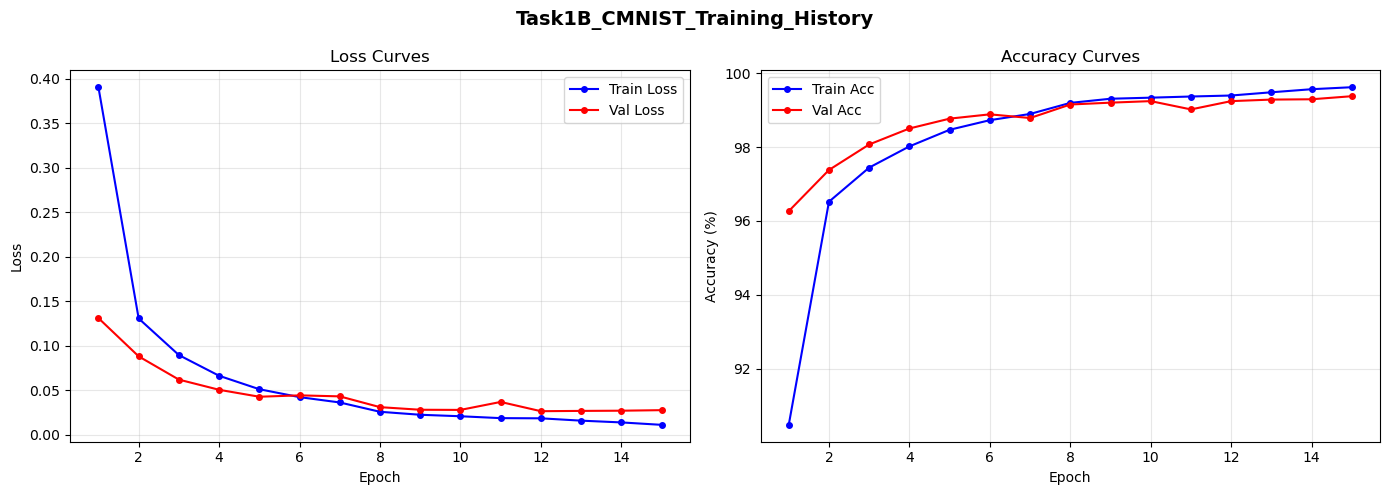


==> C-MNIST Biased Test Accuracy:   99.40%
==> C-MNIST Unbiased Test Accuracy: 90.85%
==> Accuracy Drop (shortcut learning gap): 8.55%


In [16]:
if CMNIST_LOADED:
    # Split train into train/val
    cmnist_train_size = int(0.8 * len(cmnist_train))
    cmnist_val_size   = len(cmnist_train) - cmnist_train_size
    c_train, c_val    = random_split(cmnist_train, [cmnist_train_size, cmnist_val_size],
                                     generator=torch.Generator().manual_seed(42))
    c_train_loader = DataLoader(c_train, batch_size=64, shuffle=True,  num_workers=2)
    c_val_loader   = DataLoader(c_val,   batch_size=64, shuffle=False, num_workers=2)

    print('Training CMNISTNet...')
    history_cmnist = train_model(model_cmnist, c_train_loader, c_val_loader,
                                  num_epochs=15, lr=1e-3)

    plot_history(history_cmnist, 'Task1B_CMNIST_Training_History')

    biased_acc   = evaluate(model_cmnist, cmnist_biased_loader)
    unbiased_acc = evaluate(model_cmnist, cmnist_unbiased_loader)

    print(f'\n==> C-MNIST Biased Test Accuracy:   {biased_acc:.2f}%')
    print(f'==> C-MNIST Unbiased Test Accuracy: {unbiased_acc:.2f}%')
    print(f'==> Accuracy Drop (shortcut learning gap): {biased_acc - unbiased_acc:.2f}%')
else:
    print('Skipping Task 1B training – dataset files not available.')

---
## Task 2A: Transfer Learning – ResNet-18 on STL-10

### 2A.1 – Data Loading

In [17]:
stl10_train_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(96, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4467, 0.4398, 0.4066],
                         std=[0.2603, 0.2566, 0.2713])
])

stl10_test_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4467, 0.4398, 0.4066],
                         std=[0.2603, 0.2566, 0.2713])
])

stl10_train_full = torchvision.datasets.STL10(root='./data', split='train',
                                               download=True, transform=stl10_train_transform)
stl10_test       = torchvision.datasets.STL10(root='./data', split='test',
                                               download=True, transform=stl10_test_transform)

# 80/20 train-val split
stl_train_size = int(0.8 * len(stl10_train_full))
stl_val_size   = len(stl10_train_full) - stl_train_size
stl_train, stl_val = random_split(stl10_train_full, [stl_train_size, stl_val_size],
                                   generator=torch.Generator().manual_seed(42))

stl_train_loader = DataLoader(stl_train, batch_size=32, shuffle=True,  num_workers=2)
stl_val_loader   = DataLoader(stl_val,   batch_size=32, shuffle=False, num_workers=2)
stl_test_loader  = DataLoader(stl10_test, batch_size=32, shuffle=False, num_workers=2)

print(f'STL-10 Train: {len(stl_train):,} | Val: {len(stl_val):,} | Test: {len(stl10_test):,}')
STL10_CLASSES = stl10_train_full.classes
print(f'Classes: {STL10_CLASSES}')

100%|██████████| 2.64G/2.64G [1:22:22<00:00, 534kB/s]   


Extracting ./data/stl10_binary.tar.gz to ./data
Files already downloaded and verified
STL-10 Train: 4,000 | Val: 1,000 | Test: 8,000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


### 2A.2 – Model Setup: Freeze Backbone, Replace Head

In [18]:
# Load pre-trained ResNet-18
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze ALL convolutional backbone layers
for name, param in resnet18.named_parameters():
    if 'fc' not in name:          # keep fc unfrozen (will be replaced anyway)
        param.requires_grad = False

# Replace final FC layer for 10-class STL-10
in_features = resnet18.fc.in_features   # 512 for ResNet-18
resnet18.fc = nn.Linear(in_features, 10)
# New fc is randomly initialized and requires_grad=True by default

resnet18 = resnet18.to(device)

trainable = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in resnet18.parameters() if not p.requires_grad)
print(f'Trainable parameters: {trainable:,}')
print(f'Frozen parameters:    {frozen:,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/mubeen/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:38<00:00, 1.21MB/s]

Trainable parameters: 5,130
Frozen parameters:    11,176,512


### 2A.3 – Train Classification Head

Fine-tuning ResNet-18 on STL-10...
Epoch [ 1/20] Train Loss: 1.4293 Acc: 52.45% | Val Loss: 0.9469 Acc: 69.70%
Epoch [ 5/20] Train Loss: 0.7047 Acc: 76.62% | Val Loss: 0.7568 Acc: 74.80%
Epoch [10/20] Train Loss: 0.6088 Acc: 79.62% | Val Loss: 0.7323 Acc: 76.00%
Epoch [15/20] Train Loss: 0.5815 Acc: 79.97% | Val Loss: 0.6796 Acc: 77.00%
Epoch [20/20] Train Loss: 0.5771 Acc: 79.92% | Val Loss: 0.6602 Acc: 77.70%


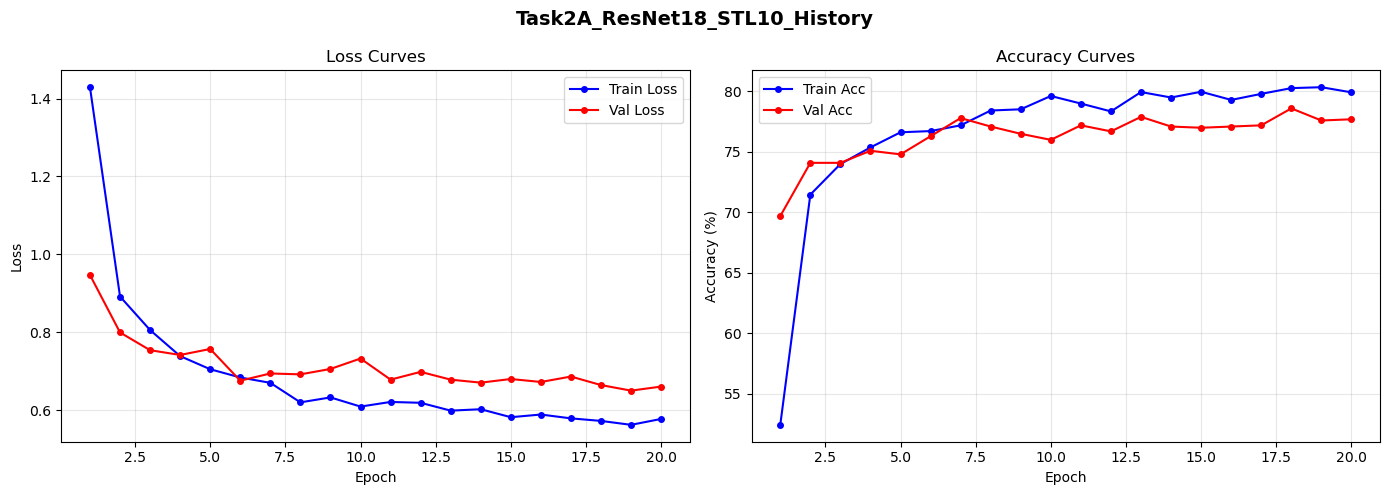


==> STL-10 Test Accuracy (ResNet-18 fine-tuned): 76.75%


In [19]:
print('Fine-tuning ResNet-18 on STL-10...')
history_resnet = train_model(resnet18, stl_train_loader, stl_val_loader,
                              num_epochs=20, lr=1e-3)

plot_history(history_resnet, 'Task2A_ResNet18_STL10_History')

stl_test_acc = evaluate(resnet18, stl_test_loader)
print(f'\n==> STL-10 Test Accuracy (ResNet-18 fine-tuned): {stl_test_acc:.2f}%')

# Save model for GradCAM use
torch.save(resnet18.state_dict(), 'resnet18_stl10.pth')

---
## Task 2B: GradCAM Visualization

### 2B.1 – GradCAM Implementation

In [23]:
class GradCAM:
    """
    Gradient-weighted Class Activation Mapping.
    Hooks into the specified target layer to extract activations and gradients.
    """
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate_cam(self, input_tensor, target_class=None):
        """
        Generate GradCAM heatmap for input_tensor.
        Returns cam as numpy array in [0,1].
        """
        self.model.eval()
        input_tensor = input_tensor.unsqueeze(0).to(device)
        input_tensor.requires_grad_(True)

        # Forward pass
        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        # Zero grads and backward for target class
        self.model.zero_grad()
        class_score = output[0, target_class]
        class_score.backward()

        # Global average pooling of gradients
        pooled_grads = self.gradients.mean(dim=[2, 3], keepdim=True)  # (1, C, 1, 1)

        # Weight activations
        cam = (pooled_grads * self.activations).sum(dim=1, keepdim=True)  # (1, 1, H, W)
        cam = F.relu(cam)

        # Normalize
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, target_class


print('GradCAM class defined.')

GradCAM class defined.


### 2B.2 – Select Images & Generate Heatmaps

In [24]:
import cv2  # For heatmap colorization and overlay

def overlay_heatmap(image_tensor, cam, alpha=0.5):
    """
    Overlay GradCAM heatmap on the original image.
    image_tensor: (3, H, W) normalized tensor
    cam: (H', W') numpy array in [0, 1]
    Returns: RGB numpy image (H, W, 3) in [0, 255]
    """
    # Denormalize image
    mean = np.array([0.4467, 0.4398, 0.4066])
    std  = np.array([0.2603, 0.2566, 0.2713])
    img  = image_tensor.permute(1, 2, 0).cpu().numpy()
    img  = std * img + mean
    img  = np.clip(img, 0, 1)
    img_uint8 = (img * 255).astype(np.uint8)

    h, w = img_uint8.shape[:2]

    # Resize CAM to image size
    cam_resized = cv2.resize(cam, (w, h))
    heatmap = cv2.applyColorMap((cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = (alpha * heatmap + (1 - alpha) * img_uint8).astype(np.uint8)
    return overlay, img_uint8


# Attach GradCAM to layer4 (final conv block of ResNet-18)
grad_cam = GradCAM(resnet18, resnet18.layer4[-1].conv2)

# Collect correct and incorrect predictions from test set
correct_samples   = []
incorrect_samples = []

resnet18.eval()
with torch.no_grad():
    for images, labels in stl_test_loader:
        images_gpu = images.to(device)
        preds = resnet18(images_gpu).argmax(dim=1).cpu()
        for i in range(len(labels)):
            if preds[i] == labels[i] and len(correct_samples) < 2:
                correct_samples.append((images[i], labels[i].item(), preds[i].item()))
            elif preds[i] != labels[i] and len(incorrect_samples) < 2:
                incorrect_samples.append((images[i], labels[i].item(), preds[i].item()))
        if len(correct_samples) >= 2 and len(incorrect_samples) >= 2:
            break

print(f'Found {len(correct_samples)} correct and {len(incorrect_samples)} incorrect samples.')

Found 2 correct and 2 incorrect samples.


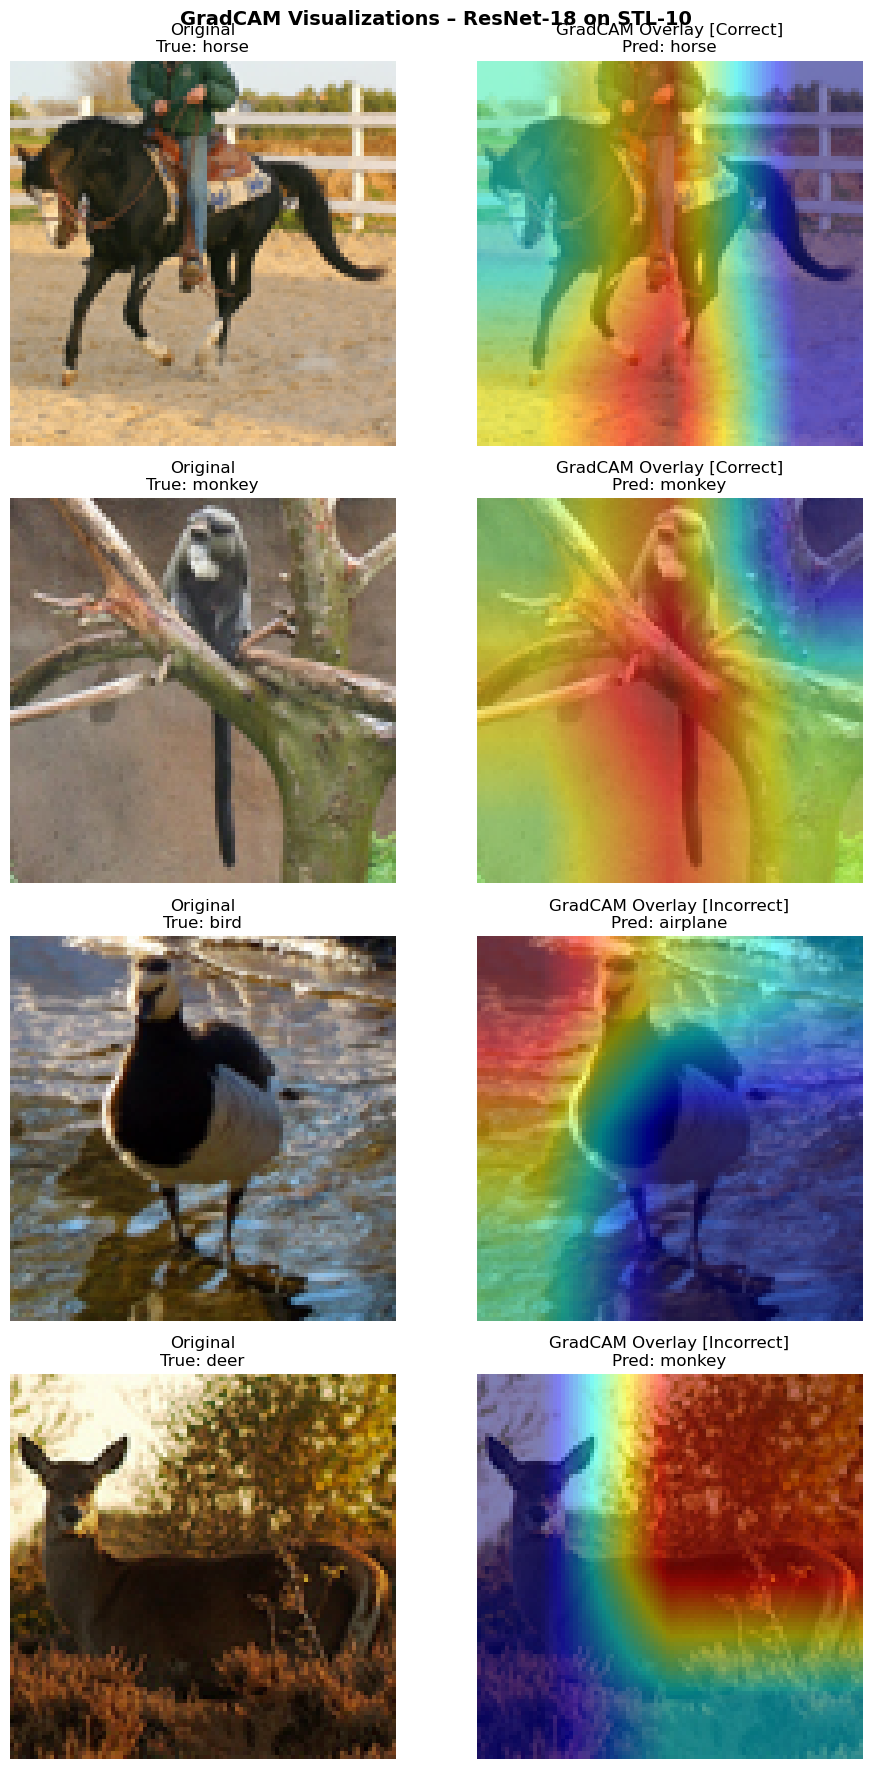

GradCAM figure saved as gradcam_results.png


In [25]:
# Generate GradCAM for all 4 samples and visualize
all_samples = correct_samples + incorrect_samples
labels_list = (['Correct'] * 2) + (['Incorrect'] * 2)

fig, axes = plt.subplots(4, 2, figsize=(10, 18))

for row, ((img_tensor, true_label, pred_label), verdict) in enumerate(zip(all_samples, labels_list)):
    cam, predicted_class = grad_cam.generate_cam(img_tensor, target_class=pred_label)
    overlay, orig = overlay_heatmap(img_tensor, cam)

    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f'Original\nTrue: {STL10_CLASSES[true_label]}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(overlay)
    axes[row, 1].set_title(
        f'GradCAM Overlay [{verdict}]\nPred: {STL10_CLASSES[pred_label]}'
    )
    axes[row, 1].axis('off')

plt.suptitle('GradCAM Visualizations – ResNet-18 on STL-10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('GradCAM figure saved as gradcam_results.png')

---
## Summary of Results

In [26]:
print('=' * 55)
print('              RESULTS SUMMARY')
print('=' * 55)
print(f'Task 1A | MNIST Test Accuracy         : {test_acc:.2f}%')
if CMNIST_LOADED:
    print(f'Task 1B | C-MNIST Biased Test Acc    : {biased_acc:.2f}%')
    print(f'Task 1B | C-MNIST Unbiased Test Acc  : {unbiased_acc:.2f}%')
print(f'Task 2A | STL-10 Test Accuracy        : {stl_test_acc:.2f}%')
print('=' * 55)

              RESULTS SUMMARY
Task 1A | MNIST Test Accuracy         : 99.27%
Task 1B | C-MNIST Biased Test Acc    : 99.40%
Task 1B | C-MNIST Unbiased Test Acc  : 90.85%
Task 2A | STL-10 Test Accuracy        : 76.75%
